In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Load Dataset
df = pd.read_excel('Sample data (1).xlsx')

In [3]:
print("=== 1. RAW DATA OVERVIEW ===")
print(f"Raw Dataset Shape: {df.shape[0]} Rows, {df.shape[1]} Columns")
print("\nRaw Missing Values Check:")
print(df.isnull().sum())

=== 1. RAW DATA OVERVIEW ===
Raw Dataset Shape: 700 Rows, 16 Columns

Raw Missing Values Check:
Segment                 0
Country                 0
Product                 0
Discount Band          53
Units Sold              0
Manufacturing Price     0
Sale Price              0
Gross Sales             0
Discounts               0
 Sales                  0
COGS                    0
Profit                  0
Date                    0
Month Number            0
Month Name              0
Year                    0
dtype: int64


In [4]:
# Create clean dataset copy (preserves raw 'df' intact)
df_clean = df.copy()

In [5]:
# 2. Data Cleaning & Standardisation-- Strip whitespace from column names 
df_clean.columns = df_clean.columns.str.strip()

In [6]:
# Handle missing values in Discount Band
df_clean['Discount Band'] = df_clean['Discount Band'].fillna('None')

In [7]:
# Feature Engineering: Calculate Profit Margin %
df_clean['Profit_Margin_%'] = np.where(
    df_clean['Sales'] > 0, 
    (df_clean['Profit'] / df_clean['Sales']) * 100, 
    0
)

In [8]:
print("\n=== 2. POST-CLEANING VALIDATION (HEAD) ===")
print(df_clean.head())


=== 2. POST-CLEANING VALIDATION (HEAD) ===
      Segment  Country    Product Discount Band  Units Sold  \
0  Government  Germany  Carretera          None      1513.0   
1  Government  Germany      Paseo          None      1006.0   
2  Government   Canada      Paseo          None      1725.0   
3  Government  Germany      Paseo          None      1513.0   
4  Government  Germany       Velo          None      1006.0   

   Manufacturing Price  Sale Price  Gross Sales  Discounts     Sales  \
0                    3         350     529550.0        0.0  529550.0   
1                   10         350     352100.0        0.0  352100.0   
2                   10         350     603750.0        0.0  603750.0   
3                   10         350     529550.0        0.0  529550.0   
4                  120         350     352100.0        0.0  352100.0   

       COGS    Profit       Date  Month Number Month Name  Year  \
0  393380.0  136170.0 2014-12-01            12   December  2014   
1  261560.

In [9]:
print("\n=== 3. POST-CLEANING SUMMARY STATS (DESCRIBE) ===")
print(df_clean.describe())


=== 3. POST-CLEANING SUMMARY STATS (DESCRIBE) ===
        Units Sold  Manufacturing Price  Sale Price   Gross Sales  \
count   700.000000           700.000000  700.000000  7.000000e+02   
mean   1608.294286            96.477143  118.428571  1.827594e+05   
min     200.000000             3.000000    7.000000  1.799000e+03   
25%     905.000000             5.000000   12.000000  1.739175e+04   
50%    1542.500000            10.000000   20.000000  3.798000e+04   
75%    2229.125000           250.000000  300.000000  2.790250e+05   
max    4492.500000           260.000000  350.000000  1.207500e+06   
std     867.427859           108.602612  136.775515  2.542623e+05   

           Discounts         Sales           COGS         Profit  \
count     700.000000  7.000000e+02     700.000000     700.000000   
mean    13150.354629  1.696091e+05  145475.211429   24133.860371   
min         0.000000  1.655080e+03     918.000000  -40617.500000   
25%       800.320000  1.592800e+04    7490.000000    28

In [10]:
print("\n=== 4. EXECUTIVE BUSINESS SUMMARY ===")
print(f"Total Gross Sales     : ${df_clean['Gross Sales'].sum():,.2f}")
print(f"Total Discounts       : ${df_clean['Discounts'].sum():,.2f}")
print(f"Total Net Sales       : ${df_clean['Sales'].sum():,.2f}")
print(f"Total COGS            : ${df_clean['COGS'].sum():,.2f}")
print(f"Total Net Profit      : ${df_clean['Profit'].sum():,.2f}")
print(f"Total Units Sold      : {df_clean['Units Sold'].sum():,.0f}")
print(f"Overall Profit Margin : {((df_clean['Profit'].sum() / df_clean['Sales'].sum()) * 100):.2f}%")


=== 4. EXECUTIVE BUSINESS SUMMARY ===
Total Gross Sales     : $127,931,598.50
Total Discounts       : $9,205,248.24
Total Net Sales       : $118,726,350.26
Total COGS            : $101,832,648.00
Total Net Profit      : $16,893,702.26
Total Units Sold      : 1,125,806
Overall Profit Margin : 14.23%


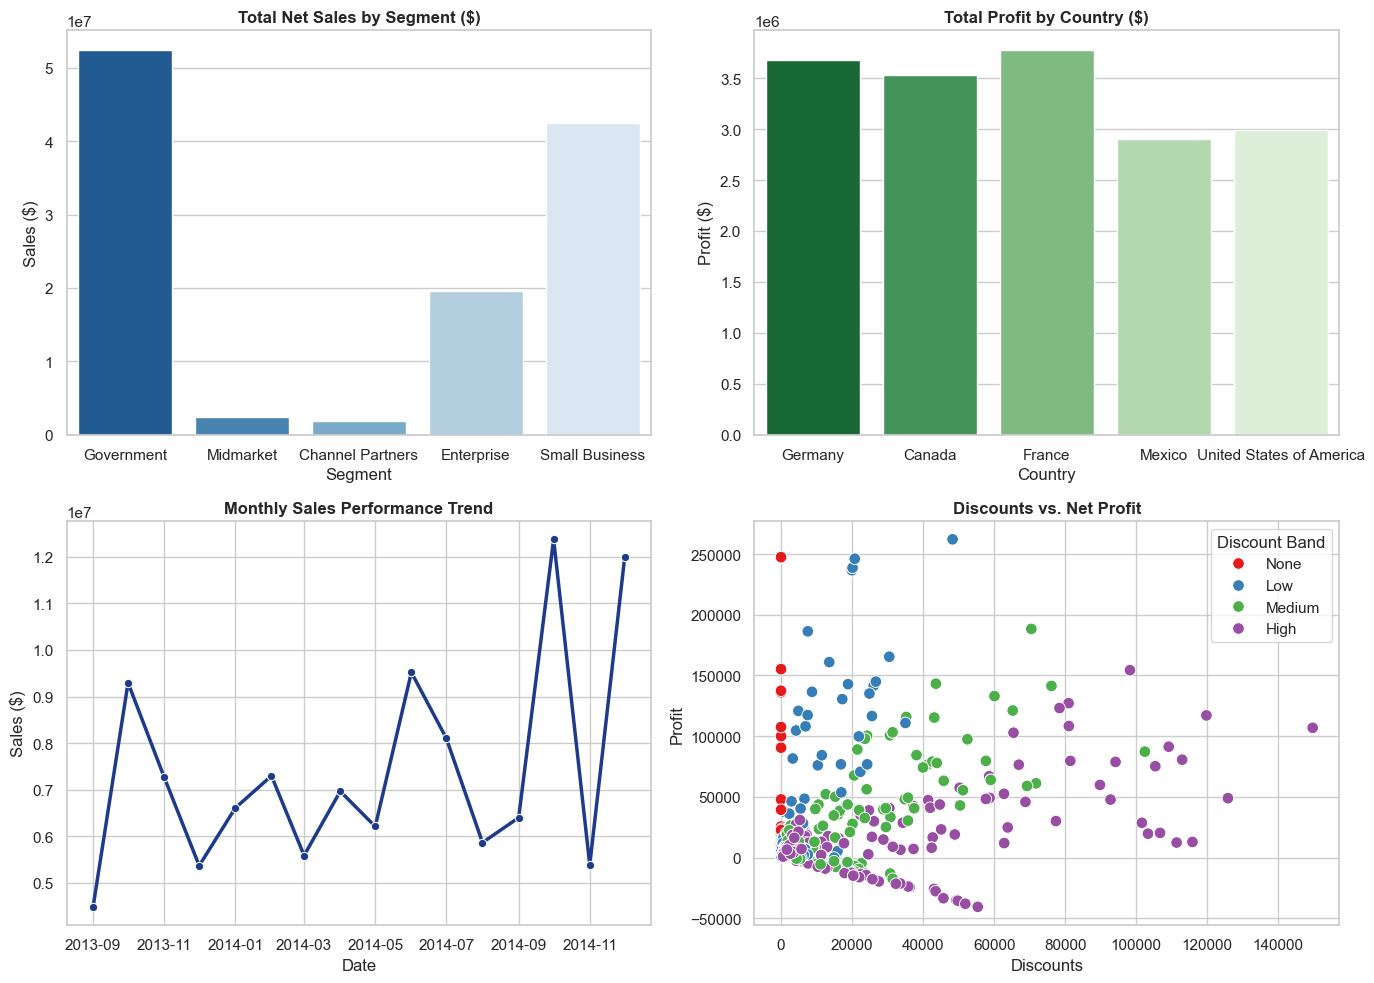

In [11]:
# ==========================================
# 4. DATA VISUALIZATION
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Visual 1: Net Sales by Segment
sns.barplot(
    data=df_clean, x='Segment', y='Sales', hue='Segment', 
    estimator=sum, errorbar=None, ax=axes[0,0], palette='Blues_r'
)
axes[0,0].set_title('Total Net Sales by Segment ($)', fontweight='bold')
axes[0,0].set_ylabel('Sales ($)')

# Visual 2: Profit by Country
sns.barplot(
    data=df_clean, x='Country', y='Profit', hue='Country', 
    estimator=sum, errorbar=None, ax=axes[0,1], palette='Greens_r'
)
axes[0,1].set_title('Total Profit by Country ($)', fontweight='bold')
axes[0,1].set_ylabel('Profit ($)')

# Visual 3: Monthly Sales Trend
monthly_sales = df_clean.groupby('Date')['Sales'].sum().reset_index()
sns.lineplot(
    data=monthly_sales, x='Date', y='Sales', 
    marker='o', ax=axes[1,0], color='#1E3A8A', lw=2.5
)
axes[1,0].set_title('Monthly Sales Performance Trend', fontweight='bold')
axes[1,0].set_ylabel('Sales ($)')

# Visual 4: Discounts vs. Profitability Correlation
sns.scatterplot(
    data=df_clean, x='Discounts', y='Profit', 
    hue='Discount Band', ax=axes[1,1], palette='Set1', s=70
)
axes[1,1].set_title('Discounts vs. Net Profit', fontweight='bold')

plt.tight_layout()
plt.show()   

In [12]:
df_clean.to_csv('Cleaned_Financial_Data.csv', index=False)
print("\nCleaned dataset exported successfully as 'Cleaned_Financial_Data.csv'!")


Cleaned dataset exported successfully as 'Cleaned_Financial_Data.csv'!


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [14]:
# PHASE 2: PREDICTIVE SALES REGRESSION MODELING: Feature Selection & Target Encoding
feature_cols = [
    'Segment', 'Country', 'Product', 'Discount Band', 
    'Units Sold', 'Manufacturing Price', 'Sale Price', 'Discounts'
]
X = pd.get_dummies(df_clean[feature_cols], drop_first=True)
y = df_clean['Sales']

In [15]:
# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
# Model Training
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [17]:
# Metric Evaluation
def eval_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

mae_lr, rmse_lr, r2_lr = eval_metrics(y_test, y_pred_lr)
mae_rf, rmse_rf, r2_rf = eval_metrics(y_test, y_pred_rf)

print("=== PHASE 2: MODEL EVALUATION METRICS ===")
print(f"Linear Regression -> MAE: ${mae_lr:,.2f} | RMSE: ${rmse_lr:,.2f} | R2: {r2_lr:.4f}")
print(f"Random Forest     -> MAE: ${mae_rf:,.2f} | RMSE: ${rmse_rf:,.2f} | R2: {r2_rf:.4f}")

=== PHASE 2: MODEL EVALUATION METRICS ===
Linear Regression -> MAE: $78,316.02 | RMSE: $110,127.44 | R2: 0.7810
Random Forest     -> MAE: $11,063.65 | RMSE: $31,391.48 | R2: 0.9822


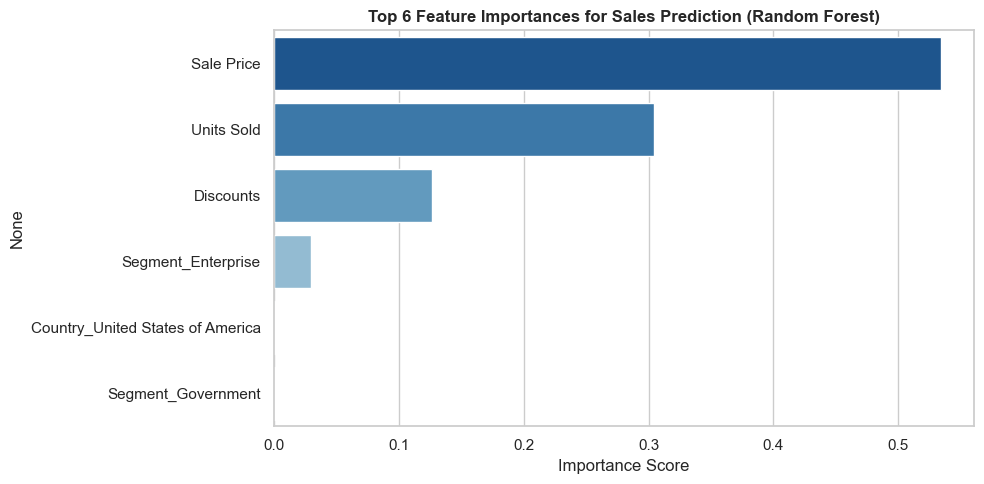

In [20]:
# Feature Importance Visualization (Warning-Free)
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=importances.head(6).values, 
    y=importances.head(6).index, 
    hue=importances.head(6).index, 
    palette='Blues_r', 
    legend=False
)
plt.title('Top 6 Feature Importances for Sales Prediction (Random Forest)', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [21]:
import os

# Automatically locate your Desktop path and export
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop", "Cleaned_Financial_Data.csv")
df_clean.to_csv(desktop_path, index=False)
print(f"File successfully saved to Desktop:\n{desktop_path}")

File successfully saved to Desktop:
C:\Users\SHeetal P\Desktop\Cleaned_Financial_Data.csv
